Escola Politécnica – University of São Paulo

Graduate Program in Mechanical Engineering

 **PME5425 – High Order Finite Element Methods with Applications in Fluid Mechanics and
Heat Transfer**

 *1st term / 2026 – Lecturers: Professors Bruno Carmo and Spencer Sherwin*

# Course Assignment 

In [26]:
!rm -rf *.chk

In [12]:
!rm -rf *.fld

In [13]:
!rm -rf *_xml

In [14]:
!rm -rf *.opt

In [15]:
!mpirun -np 2 IncNavierStokesSolver meshAG16.xml session2d.xml

	        EquationType: UnsteadyNavierStokes
	        Session Name: meshAG16
	        Spatial Dim.: 2
	  Max SEM Exp. Order: 6
	      Num. Processes: 2
	      Expansion Dim.: 2
	     Projection Type: Continuous Galerkin
	 Advect. advancement: explicit
	Diffuse. advancement: implicit
	           Time Step: 3e-05
	        No. of Steps: 333333
	 Checkpoints (steps): 3000
	    Integration Type: IMEX
	    Splitting Scheme: Velocity correction (strong press. form)
	    Smoothing-SpecHP: SVV (spectral/hp DG Kernel (diff coeff = 1*Uh/p))
Initial Conditions:
  - Field u: u_inf
  - Field v: v_inf
  - Field p: 0
Writing: "meshAG16_0.chk"
 (0.100835s, XML)
Steps: 100      Time: 0.003        CPU Time: 38.6665s
Steps: 200      Time: 0.006        CPU Time: 10.1817s
Steps: 400      Time: 0.012        CPU Time: 10.18s  
Steps: 500      Time: 0.015        CPU Time: 10.3722s
Steps: 600      Time: 0.018        CPU Time: 10.1767s
Steps: 700      Time: 0.021        CPU Time: 10.1906s
Steps: 800      Time: 0.

In [50]:
!FieldConvert -m vorticity meshAG16.xml session3d.xml meshAG16_442.chk meshAG16_3D_8.vtu


Writing: "meshAG16_3D_8.vtu"
Written file: meshAG16_3D_8.vtu


In [52]:
import pyvista as pv

# First read the VTK file
mesh = pv.read('meshAG16_3D_m2.vtu')

# Now create an itkwidget to visualise this in-browser.
pl = pv.PlotterITK()
pl.add_mesh(mesh, scalars=mesh['u'], smooth_shading=True)
pl.show(True)

Viewer(geometries=[{'vtkClass': 'vtkPolyData', 'points': {'vtkClass': 'vtkPoints', 'name': '_points', 'numberO…

Viewer(geometries=[{'vtkClass': 'vtkPolyData', 'points': {'vtkClass': 'vtkPoints', 'name': '_points', 'numberO…

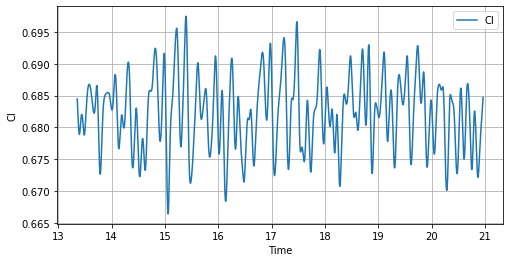

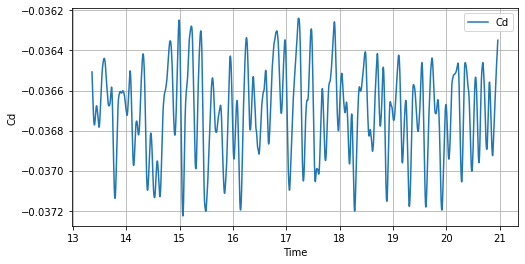

In [1]:
import numpy as np
import matplotlib.pyplot as plt
data = np.genfromtxt("3d_4_NDF_AeroForces.fce", dtype=np.float64,skip_header=6)
time = data[:,0]
fx = data[:,3]
fy = data[:,6]

# Angle of attack (degrees)
AoA = 0

# Convert to radians
alpha = np.deg2rad(AoA)

# Rotate forces into aerodynamic coordinates
Drag =  fx*np.cos(alpha) + fy*np.sin(alpha)
Lift = -fx*np.sin(alpha) + fy*np.cos(alpha)

# Lift and drag coefficients
Cd = 2*Drag
Cl = 2*Lift

# Plot Cl
plt.figure(figsize=(8,4))
plt.plot(time, Cl, label="Cl")
plt.xlabel("Time")
plt.ylabel("Cl")
plt.grid(True)
plt.legend()
plt.show()

# Plot Cd
plt.figure(figsize=(8,4))
plt.plot(time, Cd, label="Cd")
plt.xlabel("Time")
plt.ylabel("Cd")
plt.grid(True)
plt.legend()
plt.show()

Mean Cd = -0.036710
Mean Cl = 0.682264


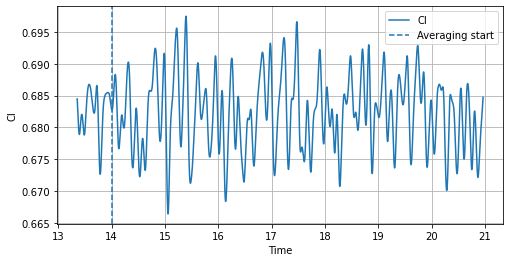

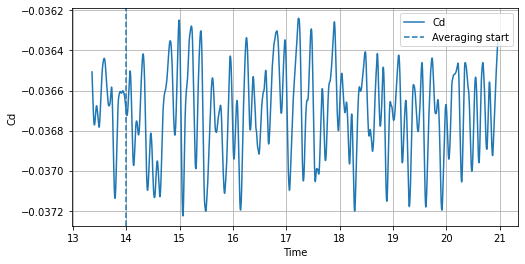

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Load aerodynamic forces file
data = np.genfromtxt("3d_4_NDF_AeroForces.fce", dtype=np.float64, skip_header=6)

time = data[:,0]
fx = data[:,3]
fy = data[:,6]

# Angle of attack (degrees)
AoA = 0
alpha = np.deg2rad(AoA)

# Rotate forces into aerodynamic coordinates
Drag =  fx*np.cos(alpha) + fy*np.sin(alpha)
Lift = -fx*np.sin(alpha) + fy*np.cos(alpha)

# Aerodynamic coefficients
Cd = 2*Drag
Cl = 2*Lift

# Choose averaging interval

t_start_avg = 14.0

mask = time >= t_start_avg

Cd_mean = np.mean(Cd[mask])
Cl_mean = np.mean(Cl[mask])

print(f"Mean Cd = {Cd_mean:.6f}")
print(f"Mean Cl = {Cl_mean:.6f}")

# --------------------------------------------------
# Plot Cl
# --------------------------------------------------

plt.figure(figsize=(8,4))
plt.plot(time, Cl, label="Cl")
plt.axvline(t_start_avg, linestyle='--', label='Averaging start')
plt.xlabel("Time")
plt.ylabel("Cl")
plt.grid(True)
plt.legend()
plt.show()

# --------------------------------------------------
# Plot Cd
# --------------------------------------------------

plt.figure(figsize=(8,4))
plt.plot(time, Cd, label="Cd")
plt.axvline(t_start_avg, linestyle='--', label='Averaging start')
plt.xlabel("Time")
plt.ylabel("Cd")
plt.grid(True)
plt.legend()
plt.show()

AoA =  -2.0° | Cl_mean =  0.021586 | Cd_mean =  0.006505
AoA =   0.0° | Cl_mean =  0.253564 | Cd_mean =  0.006760
AoA =   2.0° | Cl_mean =  0.462624 | Cd_mean =  0.008573
AoA =   4.0° | Cl_mean =  0.681318 | Cd_mean =  0.012910
AoA =   6.0° | Cl_mean =  0.885284 | Cd_mean =  0.026096
AoA =   8.0° | Cl_mean =  1.107511 | Cd_mean =  0.073914
AoA =  10.0° | Cl_mean =  1.168575 | Cd_mean =  0.088351


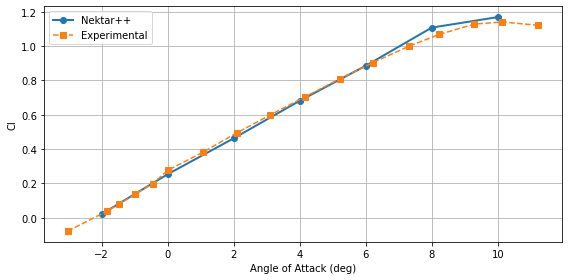

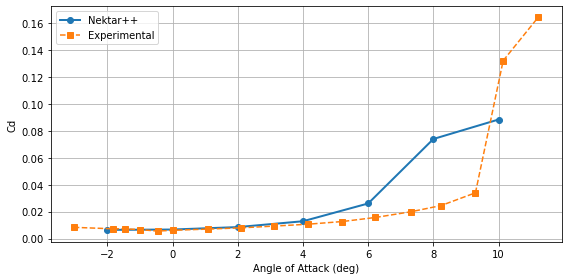

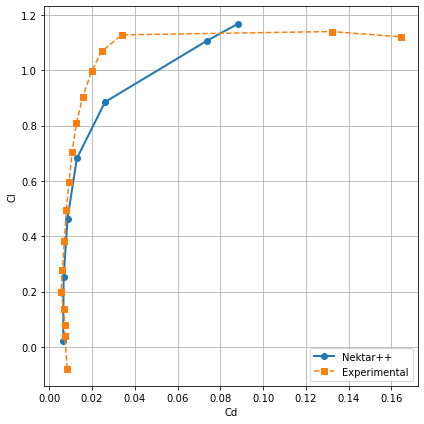

In [21]:
import numpy as np
import matplotlib.pyplot as plt


files = [
    "-2_AeroForces.fce",
    "0_AeroForces.fce",
    "2_AeroForces.fce",
    "4_2_AeroForces.fce",
    "6_AeroForces.fce",
    "8_AeroForces.fce",
    "10_AeroForces.fce",
]

AoAs = [-2, 0, 2, 4, 6, 8, 10]

t_start_avg = 6.0

# --------------------------------------------------
# Storage
# --------------------------------------------------

Cl_mean_list = []
Cd_mean_list = []

# --------------------------------------------------
# Process all files
# --------------------------------------------------

for filename, AoA in zip(files, AoAs):

    data = np.genfromtxt(
        filename,
        dtype=np.float64,
        skip_header=6
    )

    time = data[:,0]
    fx   = data[:,3]
    fy   = data[:,6]

    alpha = np.deg2rad(AoA)

    # Force rotation
    Drag =  fx*np.cos(alpha) + fy*np.sin(alpha)
    Lift = -fx*np.sin(alpha) + fy*np.cos(alpha)

    # Coefficients
    Cd = 2.0 * Drag
    Cl = 2.0 * Lift

    # Average after transient
    mask = time >= t_start_avg

    Cd_mean = np.mean(Cd[mask])
    Cl_mean = np.mean(Cl[mask])

    Cd_mean_list.append(Cd_mean)
    Cl_mean_list.append(Cl_mean)

    print(
        f"AoA = {AoA:5.1f}° | "
        f"Cl_mean = {Cl_mean: .6f} | "
        f"Cd_mean = {Cd_mean: .6f}"
    )

# Convert to arrays
AoAs = np.array(AoAs)
Cl_mean_list = np.array(Cl_mean_list)
Cd_mean_list = np.array(Cd_mean_list)

# --------------------------------------------------
# Experimental data
# --------------------------------------------------

AoA_exp = np.array([
    -3.03, -1.84, -1.47, -0.99, -0.46,
     0.02,  1.08,  2.09,  3.10,  4.15,
     5.21,  6.22,  7.30,  8.23,  9.29,
    10.14, 11.22
])

Cl_exp = np.array([
   -0.078, 0.038, 0.080, 0.136, 0.199,
    0.278, 0.383, 0.494, 0.598, 0.703,
    0.809, 0.904, 0.998, 1.068, 1.128,
    1.140, 1.121
])

Cd_exp = np.array([
    0.0084, 0.0073, 0.0073, 0.0067, 0.0056,
    0.0062, 0.0071, 0.0080, 0.0093, 0.0107,
    0.0127, 0.0157, 0.0199, 0.0245, 0.0340,
    0.1320, 0.1643
])

# --------------------------------------------------
# Cl vs AoA
# --------------------------------------------------

plt.figure(figsize=(8,4))

plt.plot(
    AoAs,
    Cl_mean_list,
    'o-',
    linewidth=2,
    label='Nektar++'
)

plt.plot(
    AoA_exp,
    Cl_exp,
    's--',
    linewidth=1.5,
    label='Experimental'
)

plt.xlabel("Angle of Attack (deg)")
plt.ylabel("Cl")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("ClxAoA.png", dpi=300)
plt.show()

# --------------------------------------------------
# Cd vs AoA
# --------------------------------------------------

plt.figure(figsize=(8,4))

plt.plot(
    AoAs,
    Cd_mean_list,
    'o-',
    linewidth=2,
    label='Nektar++'
)

plt.plot(
    AoA_exp,
    Cd_exp,
    's--',
    linewidth=1.5,
    label='Experimental'
)

plt.xlabel("Angle of Attack (deg)")
plt.ylabel("Cd")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("CdxAoA.png", dpi=300)
plt.show()

# --------------------------------------------------
# Aerodynamic polar
# --------------------------------------------------

plt.figure(figsize=(6,6))

plt.plot(
    Cd_mean_list,
    Cl_mean_list,
    'o-',
    linewidth=2,
    label='Nektar++'
)

plt.plot(
    Cd_exp,
    Cl_exp,
    's--',
    linewidth=1.5,
    label='Experimental'
)

# annotate Nektar points
for aoa, cd, cl in zip(AoAs, Cd_mean_list, Cl_mean_list):
    plt.annotate(
        f"",
        (cd, cl),
        xytext=(5,5),
        textcoords="offset points"
    )

plt.xlabel("Cd")
plt.ylabel("Cl")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("ClxCd.png", dpi=300)
plt.show()

Experimental at 6°:
Cl = 0.8833069306930694
Cd = 0.015046534653465346


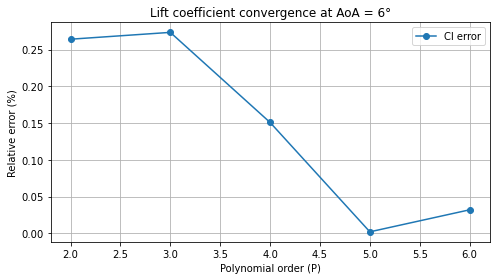

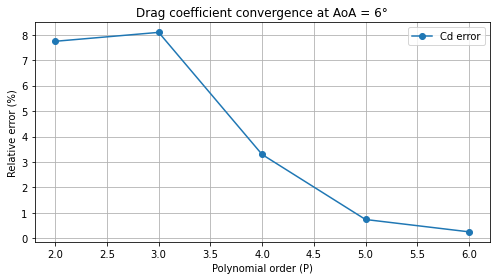

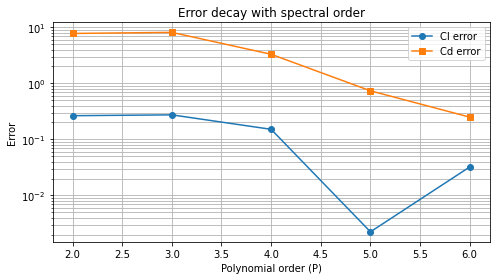

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# FILES (ALL AT AoA = 6 deg, different p-orders)
# --------------------------------------------------

files = [
    "6_p21_AeroForces.fce",
    "6_p32_AeroForces.fce",
    "6_p43_AeroForces.fce",
    "6_AeroForces.fce",
    "6_p65_AeroForces.fce",
]

poly_orders = np.array([2, 3, 4, 5, 6])

t_start_avg = 6.0

# --------------------------------------------------
# EXPERIMENTAL DATA
# --------------------------------------------------

AoA_exp = np.array([
    -3.03, -1.84, -1.47, -0.99, -0.46,
     0.02,  1.08,  2.09,  3.10,  4.15,
     5.21,  6.22,  7.30,  8.23,  9.29,
    10.14, 11.22
])

Cl_exp = np.array([
   -0.078, 0.038, 0.080, 0.136, 0.199,
    0.278, 0.383, 0.494, 0.598, 0.703,
    0.809, 0.904, 0.998, 1.068, 1.128,
    1.140, 1.121
])

Cd_exp = np.array([
    0.0084, 0.0073, 0.0073, 0.0067, 0.0056,
    0.0062, 0.0071, 0.0080, 0.0093, 0.0107,
    0.0127, 0.0157, 0.0199, 0.0245, 0.0340,
    0.1320, 0.1643
])

# --------------------------------------------------
# INTERPOLATE EXPERIMENT AT AoA = 6°
# --------------------------------------------------

Cl_exp_6 = np.interp(6.0, AoA_exp, Cl_exp)
Cd_exp_6 = np.interp(6.0, AoA_exp, Cd_exp)

print("Experimental at 6°:")
print("Cl =", Cl_exp_6)
print("Cd =", Cd_exp_6)

# --------------------------------------------------
# STORAGE
# --------------------------------------------------

Cl_mean = []
Cd_mean = []

# --------------------------------------------------
# PROCESS FILES
# --------------------------------------------------

for file in files:

    data = np.genfromtxt(file, dtype=np.float64, skip_header=6)

    time = data[:,0]
    fx   = data[:,3]
    fy   = data[:,6]

    alpha = np.deg2rad(6.0)

    Drag =  fx*np.cos(alpha) + fy*np.sin(alpha)
    Lift = -fx*np.sin(alpha) + fy*np.cos(alpha)

    Cd = 2.0 * Drag
    Cl = 2.0 * Lift

    mask = time >= t_start_avg

    Cl_mean.append(np.mean(Cl[mask]))
    Cd_mean.append(np.mean(Cd[mask]))

Cl_mean = np.array(Cl_mean)
Cd_mean = np.array(Cd_mean)

# --------------------------------------------------
# ERROR COMPUTATION
# --------------------------------------------------

Cl_err = np.abs(Cl_mean - Cl_exp_6) / np.abs(Cl_exp_6)
Cd_err = np.abs(Cd_mean - Cd_exp_6) / np.abs(Cd_exp_6)

# optional: percentage
#Cl_err *= 100
#Cd_err *= 100

# --------------------------------------------------
# PLOTS: ERROR DECAY
# --------------------------------------------------

plt.figure(figsize=(7,4))
plt.plot(poly_orders, Cl_err, 'o-', label='Cl error')
plt.xlabel("Polynomial order (P)")
plt.ylabel("Relative error (%)")
plt.title("Lift coefficient convergence at AoA = 6°")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(poly_orders, Cd_err, 'o-', label='Cd error')
plt.xlabel("Polynomial order (P)")
plt.ylabel("Relative error (%)")
plt.title("Drag coefficient convergence at AoA = 6°")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# --------------------------------------------------
# OPTIONAL: combined log plot
# --------------------------------------------------

plt.figure(figsize=(7,4))
plt.semilogy(poly_orders, Cl_err, 'o-', label='Cl error')
plt.semilogy(poly_orders, Cd_err, 's-', label='Cd error')
plt.xlabel("Polynomial order (P)")
plt.ylabel("Error")
plt.title("Error decay with spectral order")
plt.grid(True, which='both')
plt.legend()
plt.tight_layout()
plt.savefig("P convergence.png", dpi=300)
plt.show()


-2_AeroForces.fce    AoA= -2.0 Cl=0.02159 Cd=0.00650
0_AeroForces.fce     AoA=  0.0 Cl=0.25356 Cd=0.00676
2_AeroForces.fce     AoA=  2.0 Cl=0.46262 Cd=0.00857
4_2_AeroForces.fce   AoA=  4.0 Cl=0.68132 Cd=0.01291
6_AeroForces.fce     AoA=  6.0 Cl=0.88528 Cd=0.02610
8_AeroForces.fce     AoA=  8.0 Cl=1.10751 Cd=0.07391
10_AeroForces.fce    AoA= 10.0 Cl=1.16858 Cd=0.08835
3d_4_NDF_AeroForces.fce AoA=  4.0 Cl=0.68316 Cd=0.01097


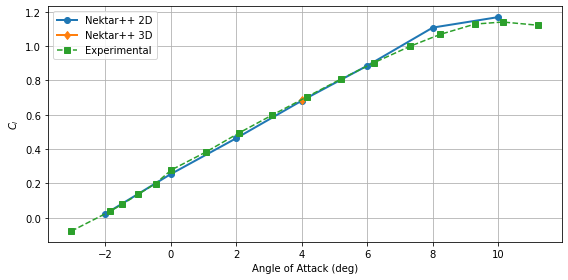

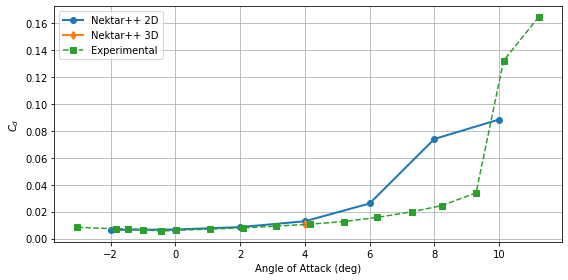

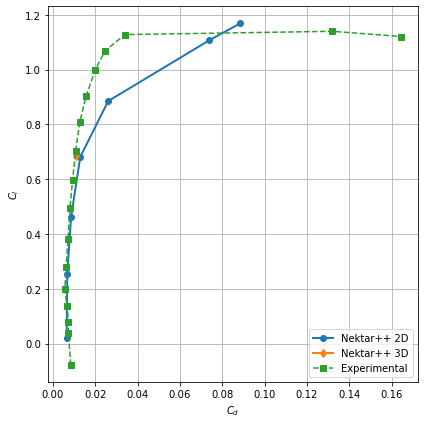

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Function to process a set of simulations
# --------------------------------------------------

def process_cases(files, AoAs, t_start_avg):

    Cl_mean_list = []
    Cd_mean_list = []

    for filename, AoA in zip(files, AoAs):

        data = np.genfromtxt(filename,
                             dtype=np.float64,
                             skip_header=6)

        time = data[:,0]
        fx   = data[:,3]
        fy   = data[:,6]

        alpha = np.deg2rad(AoA)

        Drag =  fx*np.cos(alpha) + fy*np.sin(alpha)
        Lift = -fx*np.sin(alpha) + fy*np.cos(alpha)

        Cd = 2.0 * Drag
        Cl = 2.0 * Lift

        mask = time >= t_start_avg

        Cd_mean = np.mean(Cd[mask])
        Cl_mean = np.mean(Cl[mask])

        Cd_mean_list.append(Cd_mean)
        Cl_mean_list.append(Cl_mean)

        print(
            f"{filename:20s} "
            f"AoA={AoA:5.1f} "
            f"Cl={Cl_mean:.5f} "
            f"Cd={Cd_mean:.5f}"
        )

    return np.array(Cl_mean_list), np.array(Cd_mean_list)

files_2d = [
    "-2_AeroForces.fce",
    "0_AeroForces.fce",
    "2_AeroForces.fce",
    "4_2_AeroForces.fce",
    "6_AeroForces.fce",
    "8_AeroForces.fce",
    "10_AeroForces.fce",
]

AoAs = np.array([-2,0,2,4,6,8,10])

Cl_2d, Cd_2d = process_cases(
    files_2d,
    AoAs,
    t_start_avg=6.0
)

files_3d = [
    "3d_4_NDF_AeroForces.fce"
]

AoA_3D = np.array([4])

Cl_3d, Cd_3d = process_cases(
    files_3d,
    AoA_3D,
    t_start_avg=14.0      
)


# --------------------------------------------------
# EXPERIMENTAL DATA
# --------------------------------------------------

AoA_exp = np.array([
    -3.03, -1.84, -1.47, -0.99, -0.46,
     0.02,  1.08,  2.09,  3.10,  4.15,
     5.21,  6.22,  7.30,  8.23,  9.29,
    10.14, 11.22
])

Cl_exp = np.array([
   -0.078, 0.038, 0.080, 0.136, 0.199,
    0.278, 0.383, 0.494, 0.598, 0.703,
    0.809, 0.904, 0.998, 1.068, 1.128,
    1.140, 1.121
])

Cd_exp = np.array([
    0.0084, 0.0073, 0.0073, 0.0067, 0.0056,
    0.0062, 0.0071, 0.0080, 0.0093, 0.0107,
    0.0127, 0.0157, 0.0199, 0.0245, 0.0340,
    0.1320, 0.1643
])


plt.figure(figsize=(8,4))

plt.plot(
    AoAs,
    Cl_2d,
    'o-',
    linewidth=2,
    label='Nektar++ 2D'
)

plt.plot(
    AoA_3D,
    Cl_3d,
    'd-',
    linewidth=2,
    label='Nektar++ 3D'
)

plt.plot(
    AoA_exp,
    Cl_exp,
    's--',
    linewidth=1.5,
    label='Experimental'
)

plt.xlabel("Angle of Attack (deg)")
plt.ylabel(r"$C_l$")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig("ClxAoA.png",dpi=300)
plt.show()

plt.figure(figsize=(8,4))

plt.plot(
    AoAs,
    Cd_2d,
    'o-',
    linewidth=2,
    label='Nektar++ 2D'
)

plt.plot(
    AoA_3D,
    Cd_3d,
    'd-',
    linewidth=2,
    label='Nektar++ 3D'
)

plt.plot(
    AoA_exp,
    Cd_exp,
    's--',
    linewidth=1.5,
    label='Experimental'
)

plt.xlabel("Angle of Attack (deg)")
plt.ylabel(r"$C_d$")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig("CdxAoA.png",dpi=300)
plt.show()

plt.figure(figsize=(6,6))

plt.plot(
    Cd_2d,
    Cl_2d,
    'o-',
    linewidth=2,
    label='Nektar++ 2D'
)

plt.plot(
    Cd_3d,
    Cl_3d,
    'd-',
    linewidth=2,
    label='Nektar++ 3D'
)

plt.plot(
    Cd_exp,
    Cl_exp,
    's--',
    linewidth=1.5,
    label='Experimental'
)

plt.xlabel(r"$C_d$")
plt.ylabel(r"$C_l$")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig("ClxCd.png",dpi=300)
plt.show()